**Copyright © 2025 Raphael Senn. Licensed under the MIT License.**

**Author:** Raphael Senn (<raphaelsenn@gmx.de>)

# Deep Convolutional Generative Adversarial Networks (Radford et al., 2016)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from src.models.dcgan_v1 import (
    DCGANGenerator,
    DCGANDiscriminator,
)

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

### Visualize Training Loss

In [3]:
report = pd.read_csv("dcgan_report_celeba.csv")
report.head()

,epoch,loss_generator,loss_discriminator
0,0,6.417629,0.968858
1,1,3.642023,0.813936
2,2,3.620859,0.770994
3,3,3.721281,0.711988
4,4,3.921417,0.638987


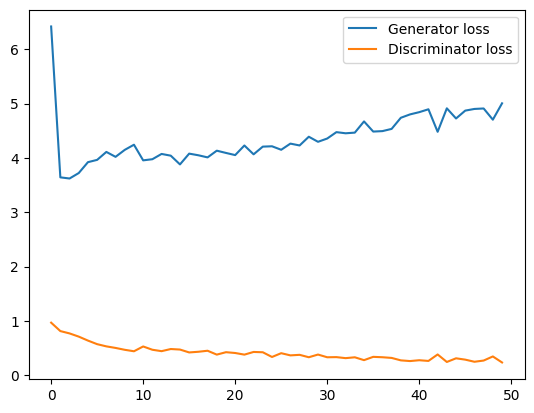

In [4]:
_, ax = plt.subplots()

ax.plot(np.arange(len(report)), report["loss_generator"], label="Generator loss")
ax.plot(np.arange(len(report)), report["loss_discriminator"], label="Discriminator loss")
ax.legend()
plt.show()

## Fake Data

In [ ]:
generator = DCGANGenerator()
discriminator = DCGANDiscriminator()

generator.load_state_dict(
    torch.load(
        "generator_ngf128_epochs50_celeba.pth", map_location="cpu", weights_only=True
    )
)
discriminator.load_state_dict(
    torch.load(
        "discriminator_ndf128_epochs50_celeba.pth", map_location="cpu", weights_only=True
        )
)

<All keys matched successfully>

In [6]:
num_params_g = sum(p.numel() for p in generator.parameters())
num_params_d = sum(p.numel() for p in discriminator.parameters())
print(f'Generator has: {num_params_g} learnable parameters')
print(f'Discrimintor has: {num_params_d} learnable parameters')

Generator has: 12658432 learnable parameters
Discrimintor has: 11036160 learnable parameters


#### Generating Fake Data

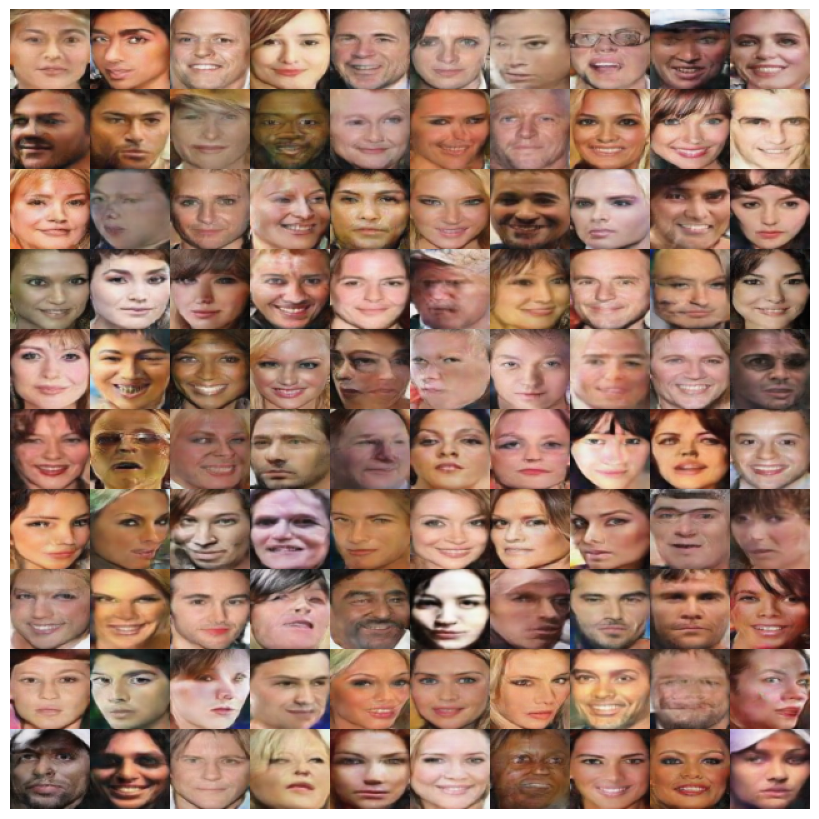

In [ ]:
FIGSIZE = (8, 8) 
ROWS = 10
COLS = 10

n_images = ROWS * COLS

noise = torch.rand((n_images, 100))*2 - 1
fake_imgs = generator(noise)        # [n_images, 3, 64, 64]
fake_imgs = fake_imgs.detach().numpy()

fig, ax = plt.subplots(nrows=ROWS, ncols=COLS, figsize=FIGSIZE)
fig.subplots_adjust(hspace=0, wspace=0, top=1, bottom=0, left=0, right=1) 
ax = ax.flatten()

for i in range(n_images):
    img = fake_imgs[i]              # [3, 64, 64]
    img = img.transpose(1, 2, 0)    # [64, 64, 3]
    img = ((img + 1) / 2).clip(0, 1)

    ax[i].imshow(img)
    ax[i].axis("off")
plt.show()